# Computer Vision 1: Assignment 2

Task 2

Group Number 43

Marek Drwal

01.12.2025

## setup

In [120]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt

## defs

In [121]:
def show_img(img, pth='', comment=''):
    plt.imshow(img, cmap=plt.cm.gray)
    plt.title(comment +' ' + pth)
    plt.show()

In [122]:
def load_display_img(pth, is_gray=False):
    img = ski.io.imread(pth)
    if not is_gray:
        show_img(img, pth, 'org')
        img = ski.color.rgb2gray(img)
    show_img(img, pth, 'gray')
    return img

In [123]:
def augment_img(img, pth='', display=True, noise_smooth=True):
    if noise_smooth:
        N = ski.util.random_noise(img, 'gaussian', var=0.01, rng=123)
        show_img(N, pth, 'noise')
        S = ski.filters.gaussian(N, sigma=1)
        show_img(S, pth, 'smooth')
        FN = ski.filters.sobel(N)
        show_img(FN, pth, 'Sobel on noise')
        FS = ski.filters.sobel(S)
        show_img(FS, pth, 'Sobel on smooth')
        return N, S, FN, FS
    FS = ski.filters.sobel(img)
    show_img(FS, pth, 'Sobel on')
    return FS

In [124]:
def plot_img_hist(img, no_bins=500):
    return plt.hist(img.ravel(), bins=no_bins, range=(0,1), histtype='step')

In [125]:
def binary_mask(img, threshold, pth='', name=''):
    masked_img = np.where(img.ravel() > threshold, True, False).reshape(img.shape)
    show_img(masked_img, pth, f'{name} masked with {threshold}')
    return masked_img

## the woman

In [126]:
pth = 'woman.png'

### imgs

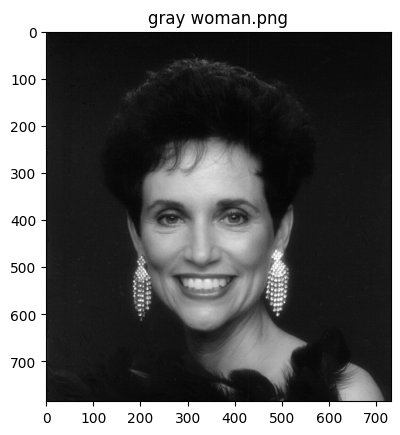

In [127]:
woman = load_display_img(pth, is_gray=True)

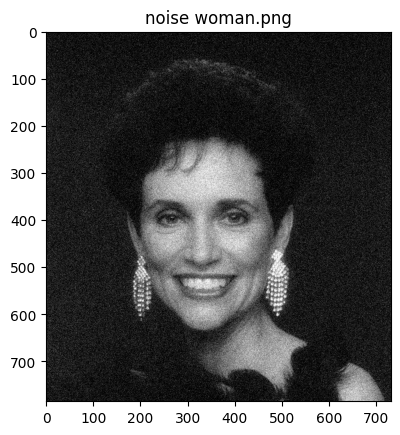

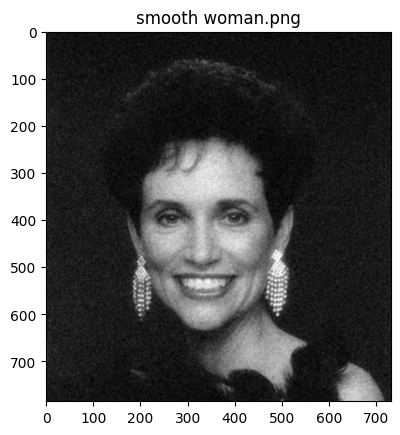

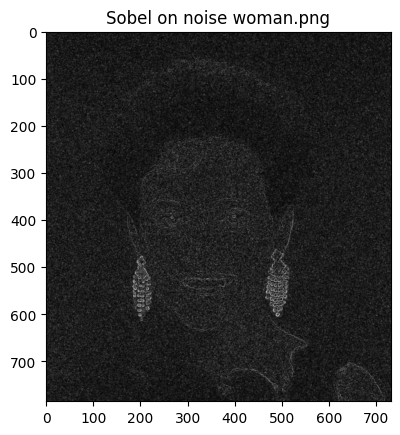

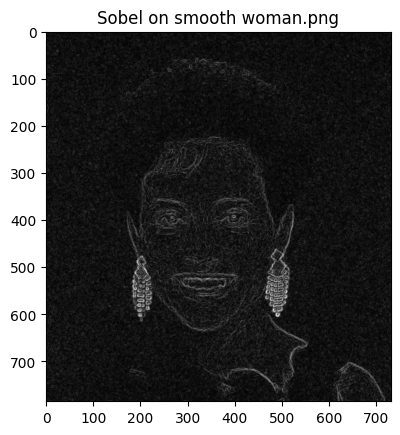

In [128]:
N, S, FN, FS = augment_img(woman, pth)

### histograms

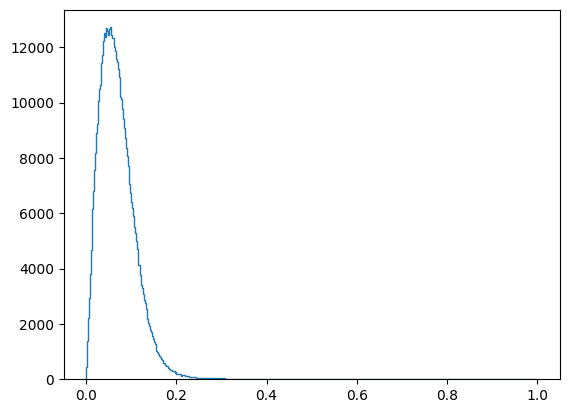

In [129]:
hist_N = plot_img_hist(FN)

In [130]:
tn = 0.17

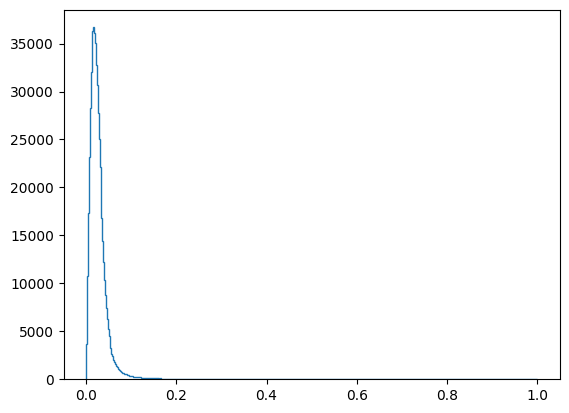

In [131]:
hist_S = plot_img_hist(FS)

In [132]:
ts = 0.075

### binary masks

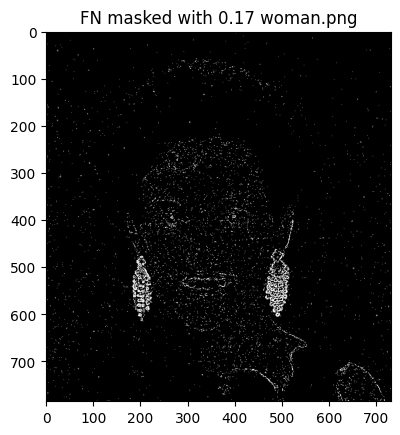

In [133]:
masked_FN = binary_mask(FN, tn, pth, 'FN')

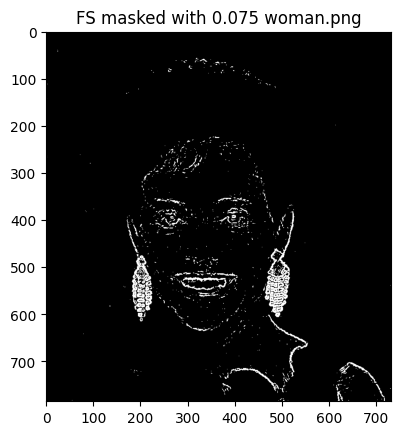

In [134]:
masked_FS = binary_mask(FS, ts, pth, 'FS')

 Why is edge detection improved by applying smoothing?
 Smoothing removes noise, which has great impact on gradients

## TRUDI

### 022

In [135]:
pth = '0222.jpg'

#### imgs

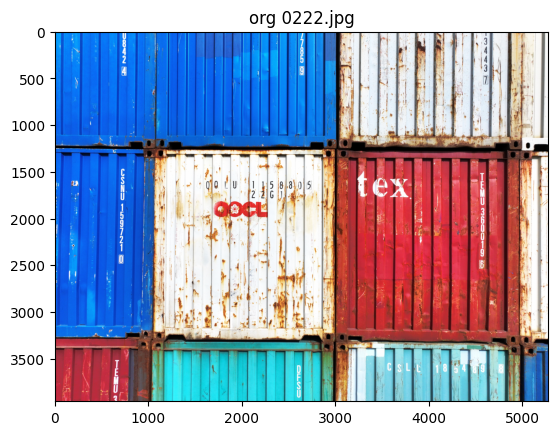

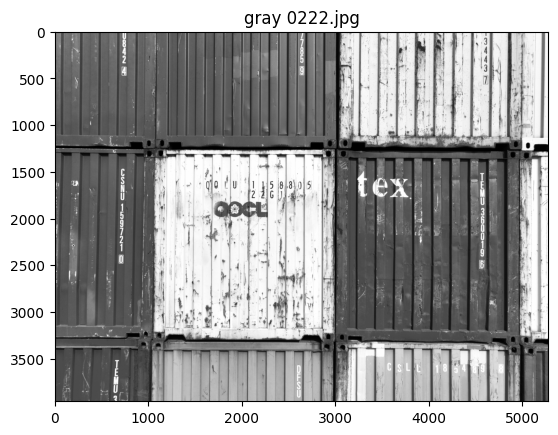

In [136]:
img = load_display_img(pth)

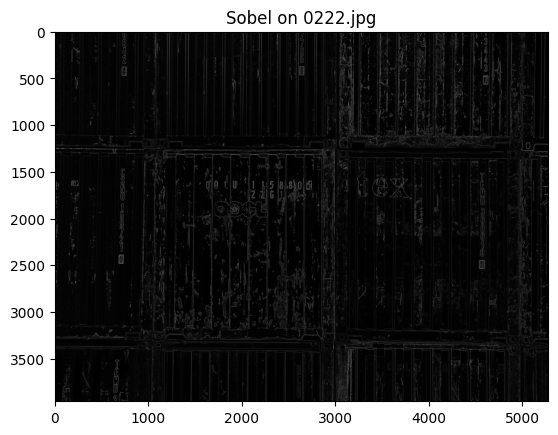

In [137]:
FS = augment_img(img, pth, noise_smooth=False)

#### histograms

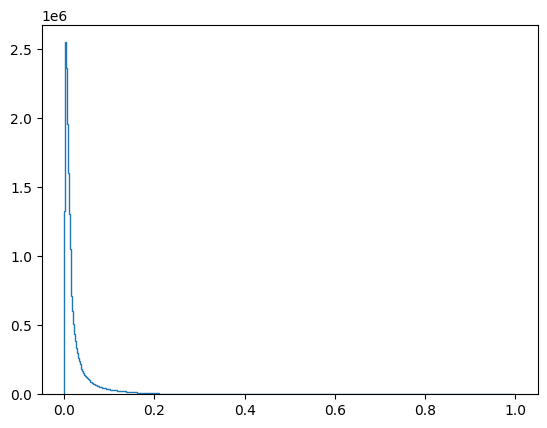

In [138]:
hist_S = plot_img_hist(FS)

In [139]:
ts = 0.075

#### binary masks

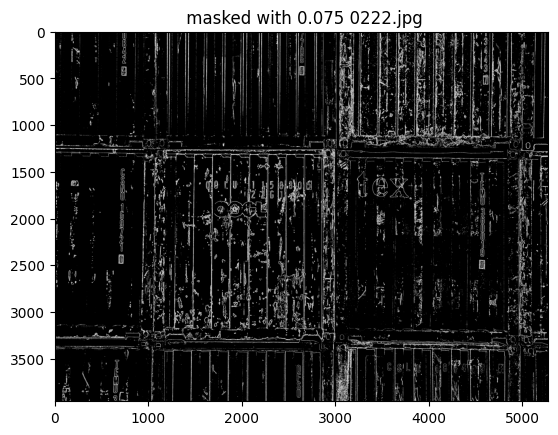

In [140]:
masked_FS = binary_mask(FS, ts, pth)

#### hysteresis

https://scikit-image.org/docs/stable/auto_examples/filters/plot_hysteresis.html

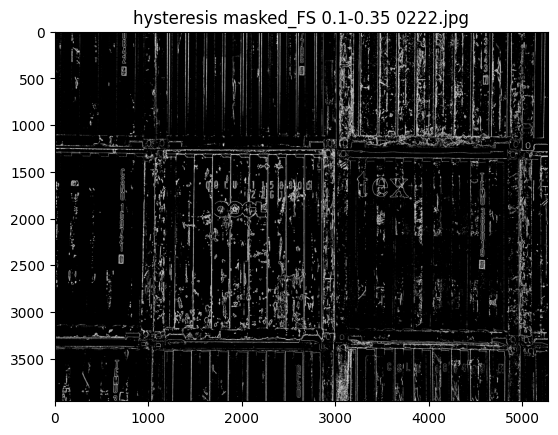

In [141]:
show_img(ski.filters.apply_hysteresis_threshold(masked_FS, 0.1, 0.35), pth, 'hysteresis masked_FS 0.1-0.35')

#### Canny

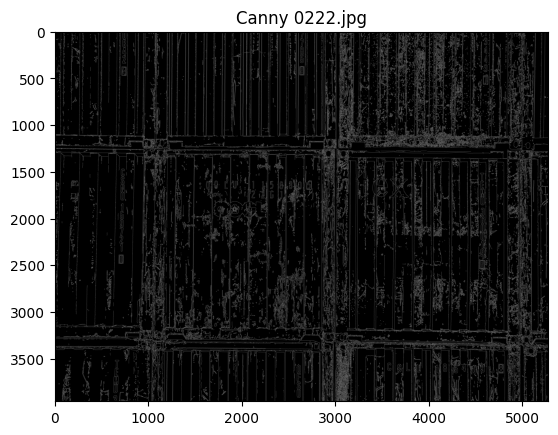

In [142]:
show_img(ski.feature.canny(img), pth, 'Canny')

### DJI

In [143]:
pth = 'DJI_0409.jpg'

#### imgs

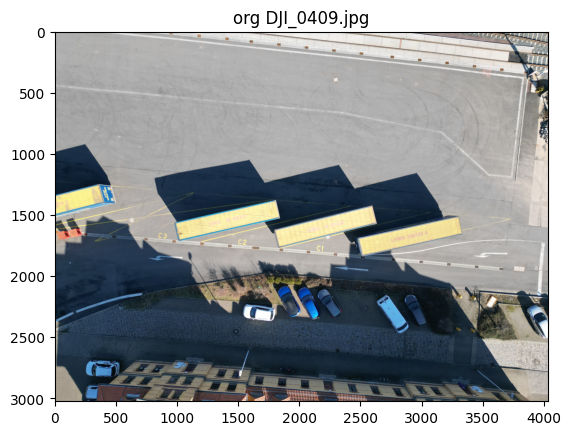

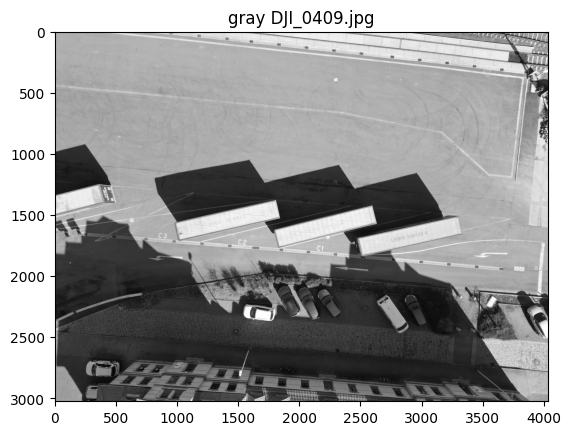

In [144]:
img = load_display_img(pth)

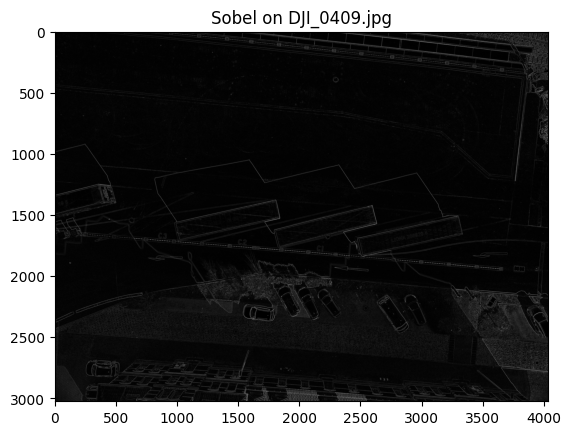

In [145]:
FS = augment_img(img, pth, noise_smooth=False)

#### histograms

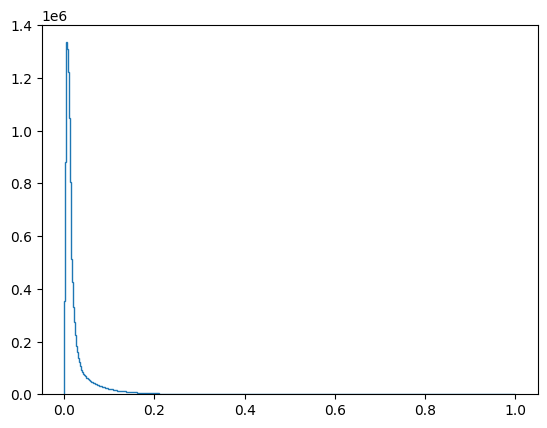

In [146]:
hist_S = plot_img_hist(FS)

In [147]:
ts = 0.075

#### binary masks

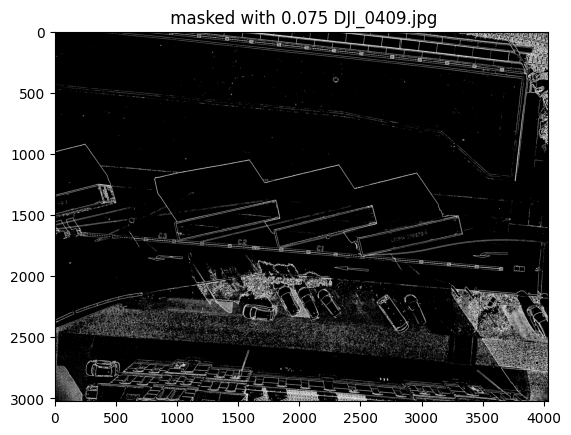

In [148]:
masked_FS = binary_mask(FS, ts, pth)

#### hysteresis

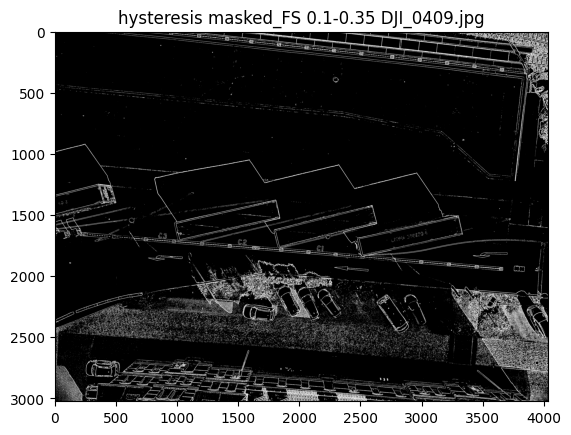

In [149]:
show_img(ski.filters.apply_hysteresis_threshold(masked_FS, 0.1, 0.35), pth, 'hysteresis masked_FS 0.1-0.35')

#### Canny

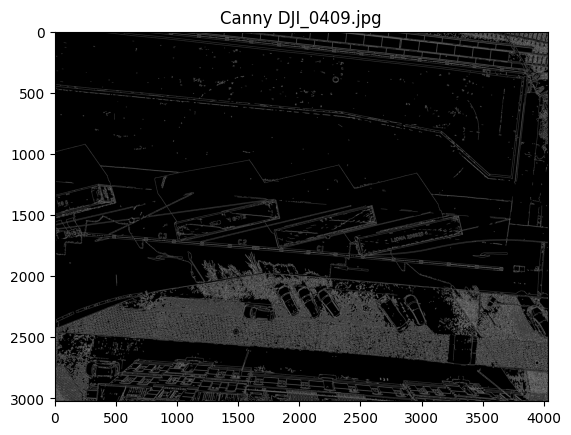

In [150]:
show_img(ski.feature.canny(img), pth, 'Canny')

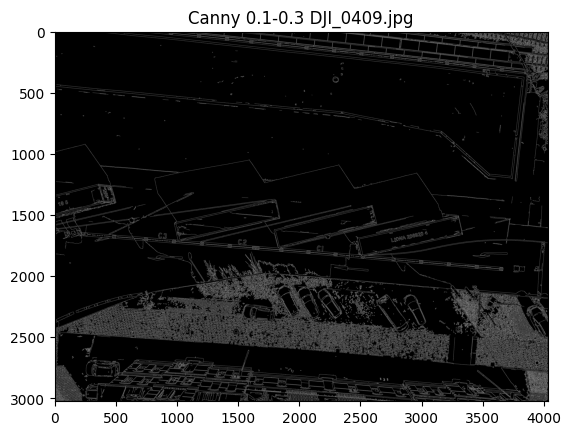

In [153]:
show_img(ski.feature.canny(img, low_threshold=0.1, high_threshold=0.3), pth, 'Canny 0.1-0.3')

Would applying non-maxima suppression and/or Hystereses thresholding help the problems with
 getting the clean contours of the objects in these images?
 Yes and combined use in Canny method should be robust and effective

If the task was counting the number of containers or semi-trailers in these images, what other
 features would be useful besides edge detection? Why?
 template matching or DoG for blobs (counting as detection)